In [5]:
import os, re, json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
    DataCollatorWithPadding, set_seed,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)

warnings.filterwarnings('ignore')
SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"SEED   : {SEED}")

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/Colab Notebooks'

Device : cuda
GPU    : NVIDIA L4
SEED   : 42
Mounted at /content/drive


In [6]:
MODEL_NAME   = 'bert-base-uncased'
MAX_LENGTH   = 128
BATCH_SIZE   = 32
LR           = 2e-5
NUM_EPOCHS   = 5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

print(f"Model      : {MODEL_NAME}")
print(f"Max length : {MAX_LENGTH}")
print(f"Batch size : {BATCH_SIZE}")
print(f"LR         : {LR}")
print(f"Epochs     : {NUM_EPOCHS}")

Model      : bert-base-uncased
Max length : 128
Batch size : 32
LR         : 2e-05
Epochs     : 5


In [7]:
DATASET_PATH = os.path.join(DRIVE_DIR, 'dataset_clean.csv')
RAW_PATH     = os.path.join(DRIVE_DIR, 'cyberbullying_tweets.csv')

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH, encoding='utf-8')
    print(f"Loaded dataset_clean.csv  ({len(df)} rows)")
else:
    df = pd.read_csv(RAW_PATH)
    df = (df.dropna(subset=['tweet_text', 'cyberbullying_type'])
            .drop_duplicates(subset=['tweet_text'])
            .reset_index(drop=True))
    print(f"[FALLBACK] Re-created from raw CSV  ({len(df)} rows)")

splits_path = os.path.join(DRIVE_DIR, 'splits.npz')
if os.path.exists(splits_path):
    sp           = np.load(splits_path, allow_pickle=True)
    idx_tr       = sp['idx_train'];  y_tr  = sp['y_train']
    idx_val      = sp['idx_val'];    y_val = sp['y_val']
    idx_te       = sp['idx_test'];   y_te  = sp['y_test']
    TARGET_NAMES = list(sp['label_classes'])
    print("Loaded splits.npz (identical split as classical.ipynb)")
else:
    raise FileNotFoundError("splits.npz not found — run classical.ipynb first.")

N_CLASSES = len(TARGET_NAMES)
print(f"\nTarget classes ({N_CLASSES}): {TARGET_NAMES}")
print(f"Train: {len(idx_tr)} | Val: {len(idx_val)} | Test: {len(idx_te)}")

Loaded dataset_clean.csv  (46017 rows)
Loaded splits.npz (identical split as classical.ipynb)

Target classes (6): ['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion']
Train: 32211 | Val: 4602 | Test: 9204


In [8]:
EMOJI_RE = re.compile(
    '[' +
    '\U0001F600-\U0001F64F'
    '\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF'
    '\U0001F1E0-\U0001F1FF'
    '\U00002700-\U000027BF'
    '\U0001F900-\U0001F9FF'
    '\u2600-\u26FF'
    '\u2700-\u27BF'
    ']+',
    flags=re.UNICODE,
)

def light_preprocess(text: str) -> str:
    """Light preprocessing for BERT — preserve linguistic structure."""
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r'^["\u201C\u201D]+|["\u201C\u201D]+$', '', text)
    text = EMOJI_RE.sub(' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['bert_text'] = df['tweet_text'].apply(light_preprocess)

empty_mask = df['bert_text'].str.len() == 0
df.loc[empty_mask, 'bert_text'] = df.loc[empty_mask, 'tweet_text'].fillna('').str.strip()
print(f"Empty after light_preprocess (fallback): {empty_mask.sum()}")

X_tr  = df['bert_text'].values[idx_tr]
X_val = df['bert_text'].values[idx_val]
X_te  = df['bert_text'].values[idx_te]
print(f"Texts ready  — Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_te)}")

Empty after light_preprocess (fallback): 219
Texts ready  — Train: 32211 | Val: 4602 | Test: 9204


In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")

class CyberbullyingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=False,
            max_length=max_length,
            return_tensors=None,
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]))
        return item

train_ds = CyberbullyingDataset(X_tr,  y_tr,  tokenizer, MAX_LENGTH)
val_ds   = CyberbullyingDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_ds  = CyberbullyingDataset(X_te,  y_te,  tokenizer, MAX_LENGTH)
print(f"Datasets: train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: bert-base-uncased
Datasets: train=32211 | val=4602 | test=9204


In [10]:
cw_values = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
CLASS_WEIGHTS = torch.tensor(cw_values, dtype=torch.float).to(DEVICE)

print("Class weights (balanced):")
for cls, w in zip(TARGET_NAMES, cw_values):
    print(f"  {cls:<25}  {w:.4f}")

Class weights (balanced):
  age                        0.9597
  ethnicity                  0.9643
  gender                     0.9711
  not_cyberbullying          0.9663
  other_cyberbullying        1.2285
  religion                   0.9593


In [11]:
model_3a = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=N_CLASSES)
n_params  = sum(p.numel() for p in model_3a.parameters()) / 1e6
print(f"BERT parameters: {n_params:.1f}M")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy' : float(accuracy_score(labels, preds)),
        'f1_macro' : float(f1_score(labels, preds, average='macro', zero_division=0)),
    }

training_args_3a = TrainingArguments(
    output_dir                  = os.path.join(DRIVE_DIR, 'bert_3a_ckpt'),
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = LR,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    lr_scheduler_type           = 'linear',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_strategy            = 'epoch',
    save_total_limit            = 2,
    report_to                   = 'none',
    seed                        = SEED,
)

trainer_3a = WeightedTrainer(
    model           = model_3a,
    args            = training_args_3a,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = DataCollatorWithPadding(tokenizer),
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Training Tier 3A (BERT + weighted loss)...")
t0 = time.time()
trainer_3a.train()
tt_3a = time.time() - t0
print(f"Training done in {tt_3a/60:.1f} min")
trainer_3a.save_model(os.path.join(DRIVE_DIR, 'bert_3a_best'))

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

BERT parameters: 109.5M
Training Tier 3A (BERT + weighted loss)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.716415,0.374527,0.859192,0.850265
2,0.309069,0.329258,0.873533,0.866249
3,0.217221,0.357500,0.872229,0.865201
4,0.138418,0.422469,0.874620,0.868315
5,0.090028,0.495977,0.873533,0.866745


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training done in 15.9 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
def get_predictions(trainer, dataset):
    """Run inference and return (predictions, probabilities)."""
    output  = trainer.predict(dataset)
    logits  = output.predictions
    probs   = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds   = np.argmax(logits, axis=1)
    return preds, probs

print("Running inference on test set (Tier 3A)...")
t0 = time.time()
pred_3a, probs_3a_test = get_predictions(trainer_3a, test_ds)
inf_3a = time.time() - t0

result_3a = {
    'tier'            : 'Tier 3A',
    'model'           : 'BERT + Weighted Loss',
    'accuracy'        : accuracy_score(y_te, pred_3a),
    'precision'       : precision_score(y_te, pred_3a, average='macro', zero_division=0),
    'recall'          : recall_score(y_te, pred_3a, average='macro', zero_division=0),
    'f1'              : f1_score(y_te, pred_3a, average='macro', zero_division=0),
    'train_time_s'    : tt_3a,
    'inference_time_s': inf_3a,
}

print(f"\nTier 3A  →  Acc={result_3a['accuracy']:.4f}  |  F1={result_3a['f1']:.4f}")
print()
print(classification_report(y_te, pred_3a, target_names=TARGET_NAMES, digits=4))

Running inference on test set (Tier 3A)...



Tier 3A  →  Acc=0.8684  |  F1=0.8615

                     precision    recall  f1-score   support

                age     0.9704    0.9856    0.9780      1599
          ethnicity     0.9829    0.9736    0.9782      1590
             gender     0.9090    0.8975    0.9032      1580
  not_cyberbullying     0.7164    0.6415    0.6769      1587
other_cyberbullying     0.6322    0.7238    0.6749      1249
           religion     0.9592    0.9562    0.9577      1599

           accuracy                         0.8684      9204
          macro avg     0.8617    0.8630    0.8615      9204
       weighted avg     0.8704    0.8684    0.8686      9204



In [13]:
print("Extracting BERT probability vectors...")

_, probs_3a_val = get_predictions(trainer_3a,
    CyberbullyingDataset(X_val, y_val, tokenizer, MAX_LENGTH))
print(f"  Val   probs shape : {probs_3a_val.shape}")
print(f"  Test  probs shape : {probs_3a_test.shape}  (already computed)")
print("BERT probability extraction complete")

Extracting BERT probability vectors...


  Val   probs shape : (4602, 6)
  Test  probs shape : (9204, 6)  (already computed)
BERT probability extraction complete


In [14]:
with open(os.path.join(DRIVE_DIR, 'best_classical_ml_name.txt')) as f:
    best_ml_name = f.read().strip()
with open(os.path.join(DRIVE_DIR, 'tfidf_vectorizer.pkl'), 'rb') as f:
    tfidf = pickle.load(f)
with open(os.path.join(DRIVE_DIR, 'best_classical_ml.pkl'), 'rb') as f:
    best_ml = pickle.load(f)

print(f"Classical ML model loaded: {best_ml_name}")
print(f"TF-IDF vectorizer loaded")

if 'clean_text' not in df.columns:
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords', quiet=True)
    STOP_EN = set(stopwords.words('english'))

    def preprocess_ml(text: str) -> str:
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r'http\S+|www\.\S+', ' ', text)
        text = re.sub(r'@\w+|#\w+|\d+', ' ', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = [t for t in text.split() if t not in STOP_EN and len(t) > 1]
        return ' '.join(tokens)

    df['clean_text'] = df['tweet_text'].apply(preprocess_ml)
    empty_mask = df['clean_text'].str.len() == 0
    df.loc[empty_mask, 'clean_text'] = df.loc[empty_mask, 'tweet_text'].str.lower().fillna('')
    print("Recomputed clean_text (not found in CSV)")

X_val_ml = tfidf.transform(df['clean_text'].values[idx_val])
X_te_ml  = tfidf.transform(df['clean_text'].values[idx_te])

probs_ml_val  = best_ml.predict_proba(X_val_ml)

t0_ml = time.time()
probs_ml_test = best_ml.predict_proba(X_te_ml)
inf_ml = time.time() - t0_ml

print(f"Classical ML val  probs: {probs_ml_val.shape}")
print(f"Classical ML test probs: {probs_ml_test.shape}")
print(f"Classical ML test inference: {inf_ml:.4f}s")

Classical ML model loaded: Stacking (DT+RF+XGB)
TF-IDF vectorizer loaded
Classical ML val  probs: (4602, 6)
Classical ML test probs: (9204, 6)
Classical ML test inference: 0.5517s


In [15]:
X_meta_val  = np.concatenate([probs_3a_val,  probs_ml_val],  axis=1)
X_meta_test = np.concatenate([probs_3a_test, probs_ml_test], axis=1)

print(f"Meta-feature shape: train(val)={X_meta_val.shape}  |  test={X_meta_test.shape}")

meta_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
t0 = time.time()
meta_lr.fit(X_meta_val, y_val)
tt_meta = time.time() - t0
print(f"Meta-LR trained in {tt_meta:.2f}s")

t1 = time.time()
pred_3b   = meta_lr.predict(X_meta_test)
inf_3b    = time.time() - t1

result_3b = {
    'tier'            : 'Tier 3B',
    'model'           : f'Enhanced BERT (BERT + {best_ml_name} + Meta-LR)',
    'accuracy'        : accuracy_score(y_te, pred_3b),
    'precision'       : precision_score(y_te, pred_3b, average='macro', zero_division=0),
    'recall'          : recall_score(y_te, pred_3b, average='macro', zero_division=0),
    'f1'              : f1_score(y_te, pred_3b, average='macro', zero_division=0),
    'train_time_s'    : tt_3a + tt_meta,
     'inference_time_s': inf_3a + inf_ml + inf_3b,
}

print(f"\nEnhanced BERT (3B)  →  Acc={result_3b['accuracy']:.4f}  |  F1={result_3b['f1']:.4f}")
print()
print(classification_report(y_te, pred_3b, target_names=TARGET_NAMES, digits=4))

Meta-feature shape: train(val)=(4602, 12)  |  test=(9204, 12)
Meta-LR trained in 0.07s

Enhanced BERT (3B)  →  Acc=0.8721  |  F1=0.8662

                     precision    recall  f1-score   support

                age     0.9789    0.9850    0.9819      1599
          ethnicity     0.9929    0.9736    0.9832      1590
             gender     0.9138    0.8994    0.9065      1580
  not_cyberbullying     0.6935    0.6843    0.6889      1587
other_cyberbullying     0.6437    0.7030    0.6720      1249
           religion     0.9794    0.9500    0.9644      1599

           accuracy                         0.8721      9204
          macro avg     0.8670    0.8659    0.8662      9204
       weighted avg     0.8755    0.8721    0.8736      9204



In [16]:
with open(os.path.join(DRIVE_DIR, 'classical_ml_output.json')) as f:
    classical_output = json.load(f)

all_results = classical_output['results'] + [result_3a, result_3b]
full_df     = pd.DataFrame(all_results)[[
    'tier', 'model', 'accuracy', 'precision', 'recall', 'f1', 'train_time_s'
]].round(4)

print("=" * 110)
print(f"FULL COMPARISON — All Tiers  (Test Set, n={len(y_te)})")
print("=" * 110)
print(full_df.to_string(index=False))

FULL COMPARISON — All Tiers  (Test Set, n=9204)
   tier                                                 model  accuracy  precision  recall     f1  train_time_s
 Tier 1                                                    LR    0.8292     0.8218  0.8179 0.8190       20.7707
 Tier 1                                                    NB    0.7581     0.7396  0.7382 0.7113        0.0142
 Tier 1                                                   SVM    0.8321     0.8214  0.8220 0.8216        3.6130
 Tier 1                                                    RF    0.8342     0.8293  0.8213 0.8231       39.6627
 Tier 1                                                   KNN    0.6945     0.7120  0.6853 0.6927        0.0030
Tier 2A                                WSV (LR+NB+SVM+RF+KNN)    0.8337     0.8240  0.8224 0.8227       64.0636
Tier 2B                               Hard Voting (DT+RF+XGB)    0.8349     0.8323  0.8215 0.8237      230.0813
Tier 2C                                  Stacking (LR+NB

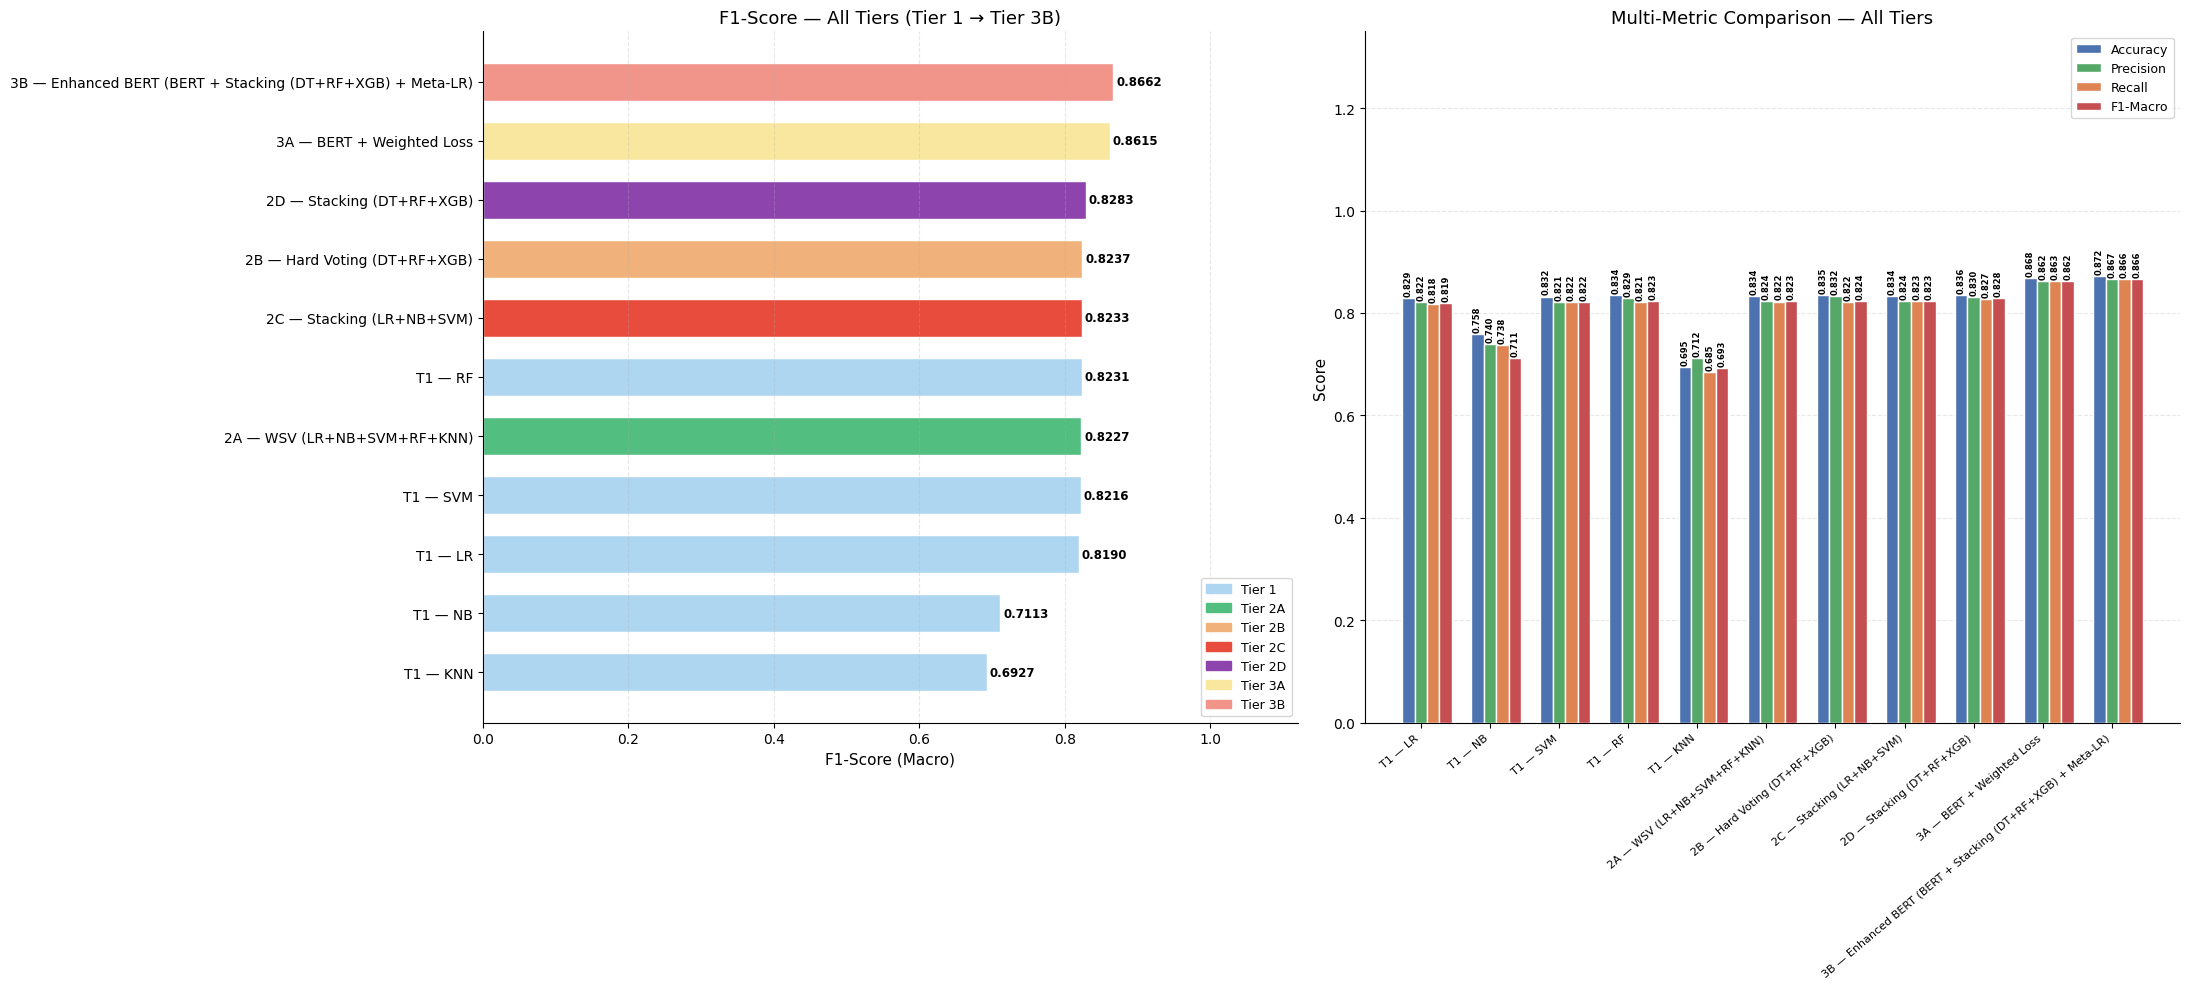

In [17]:
TIER_COLORS = {
    'Tier 1' : '#AED6F1',
    'Tier 2A': '#52BE80',
    'Tier 2B': '#F0B27A',
    'Tier 2C': '#E74C3C',
    'Tier 2D': '#8E44AD',
    'Tier 3A': '#F9E79F',
    'Tier 3B': '#F1948A',
}

def make_display_label(row):
    tier  = row['tier']
    model = row['model']
    if tier == 'Tier 1':
        return f"T1 — {model}"
    return f"{tier[-2:]} — {model}"

full_df['display'] = full_df.apply(make_display_label, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

ax1    = axes[0]
rdf_s  = full_df.sort_values('f1', ascending=True)
colors = [TIER_COLORS.get(t, '#AAAAAA') for t in rdf_s['tier']]
bars   = ax1.barh(rdf_s['display'], rdf_s['f1'],
                  color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, rdf_s['f1']):
    ax1.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold')

ax1.set_xlabel('F1-Score (Macro)', fontsize=11)
ax1.set_title('F1-Score — All Tiers (Tier 1 → Tier 3B)', fontsize=13)
ax1.set_xlim(0, 1.12)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.spines[['top', 'right']].set_visible(False)
patches = [mpatches.Patch(color=c, label=t) for t, c in TIER_COLORS.items()]
ax1.legend(handles=patches, loc='lower right', fontsize=9)

ax2     = axes[1]
METRICS = ['accuracy', 'precision', 'recall', 'f1']
MET_LBL = ['Accuracy', 'Precision', 'Recall', 'F1-Macro']
MC      = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
x       = np.arange(len(full_df))
w       = 0.18

for i, (m, lbl, color) in enumerate(zip(METRICS, MET_LBL, MC)):
    offset = (i - 1.5) * w + w / 2
    b      = ax2.bar(x + offset, full_df[m], w, label=lbl,
                     color=color, edgecolor='white', zorder=3)
    for bi, vi in zip(b, full_df[m]):
        ax2.text(bi.get_x() + bi.get_width()/2, bi.get_height() + 0.004,
                 f'{vi:.3f}', ha='center', va='bottom',
                 fontsize=6, fontweight='bold', rotation=90)

ax2.set_xticks(x)
ax2.set_xticklabels(full_df['display'], rotation=40, ha='right', fontsize=8)
ax2.set_ylim(0, 1.35)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Multi-Metric Comparison — All Tiers', fontsize=13)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'chart_full_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

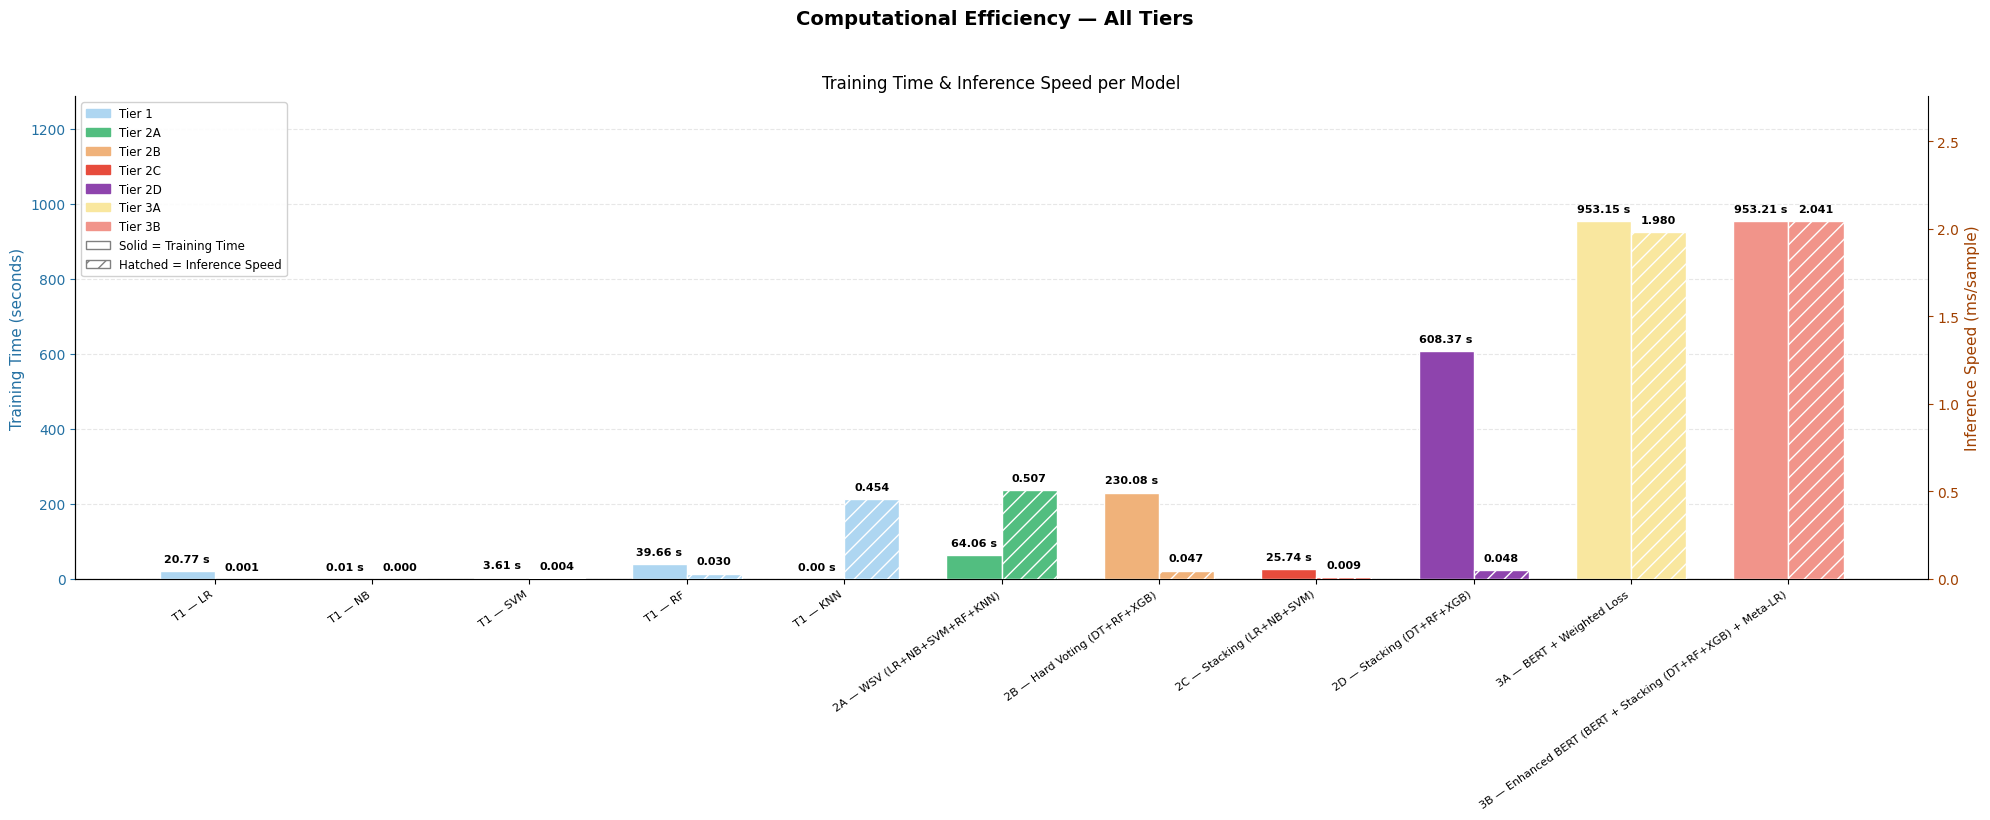

chart_full_efficiency.png saved


In [18]:
TIER_COLORS = {
    'Tier 1' : '#AED6F1',
    'Tier 2A': '#52BE80',
    'Tier 2B': '#F0B27A',
    'Tier 2C': '#E74C3C',
    'Tier 2D': '#8E44AD',
    'Tier 3A': '#F9E79F',
    'Tier 3B': '#F1948A',
}

n_test = len(y_te)
eff_df = pd.DataFrame(all_results).copy()
eff_df['train_time_sec'] = eff_df['train_time_s']
eff_df['ms_per_sample'] = (eff_df['inference_time_s'] / n_test) * 1000
eff_df['display'] = eff_df.apply(make_display_label,axis=1)
eff_df['color'] = eff_df['tier'].map(TIER_COLORS)
fig, ax1 = plt.subplots(figsize=(20, 8))
fig.suptitle('Computational Efficiency — All Tiers',fontsize=14,fontweight='bold',y=1.02)

n = len(eff_df)
x = np.arange(n)
w = 0.35

bars1 = ax1.bar(x - w/2,eff_df['train_time_sec'],width=w,color=eff_df['color'],edgecolor='white',zorder=3,)

for bar, val_sec in zip(bars1,eff_df['train_time_sec']):

    ax1.text(bar.get_x() + bar.get_width()/2,bar.get_height()+ eff_df['train_time_sec'].max()*0.02,f'{val_sec:.2f} s',ha='center',va='bottom',fontsize=8,fontweight='bold')

ax1.set_ylabel('Training Time (seconds)',fontsize=11,color='#2471A3')
ax1.tick_params(axis='y',colors='#2471A3')

ax1.set_ylim(0,eff_df['train_time_sec'].max()*1.35)

ax2 = ax1.twinx()

bars2 = ax2.bar(x + w/2,eff_df['ms_per_sample'],width=w,color=eff_df['color'],edgecolor='white',hatch='//',zorder=3,)

for bar, val in zip(bars2,eff_df['ms_per_sample']):
    ax2.text(bar.get_x() + bar.get_width()/2,bar.get_height()+ eff_df['ms_per_sample'].max()*0.02,f'{val:.3f}',ha='center',va='bottom',fontsize=8,fontweight='bold')
ax2.set_ylabel('Inference Speed (ms/sample)',fontsize=11,color='#A04000')
ax2.tick_params(axis='y',colors='#A04000')

ax2.set_ylim(0,eff_df['ms_per_sample'].max()*1.35)
ax1.set_xticks(x)

ax1.set_xticklabels(eff_df['display'],rotation=35,ha='right',fontsize=8)
ax1.set_title('Training Time & Inference Speed per Model',fontsize=12)
ax1.grid(axis='y',linestyle='--',alpha=0.3,zorder=0)

ax1.spines[['top', 'right']].set_visible(False)

ax2.spines[['top']].set_visible(False)

tier_patches = [
    mpatches.Patch(
        color=c,
        label=t
    )
    for t, c in TIER_COLORS.items()
    if t in eff_df['tier'].values
]
style_patches = [
    mpatches.Patch(
        facecolor='white',
        edgecolor='gray',
        label='Solid = Training Time'
    ),
    mpatches.Patch(
        facecolor='white',
        edgecolor='gray',
        hatch='//',
        label='Hatched = Inference Speed'
    ),
]
ax1.legend(handles=tier_patches + style_patches,loc='upper left',fontsize=8.5,framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR,'chart_full_efficiency.png'),dpi=200,bbox_inches='tight')
plt.show()
print("chart_full_efficiency.png saved")

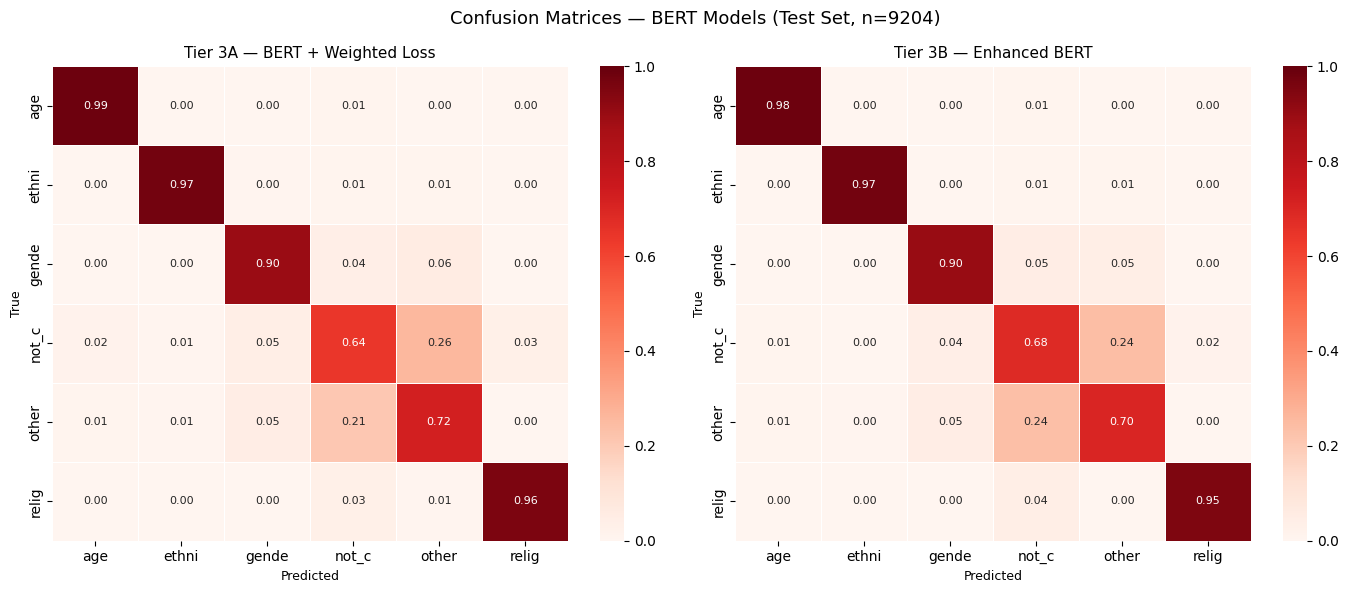

In [19]:
SHORT = [n[:5] for n in TARGET_NAMES]

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
for ax, (label, pred) in zip(axes2,
        [('Tier 3A — BERT + Weighted Loss', pred_3a),
         ('Tier 3B — Enhanced BERT',         pred_3b)]):
    cm_norm = confusion_matrix(y_te, pred, normalize='true')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                xticklabels=SHORT, yticklabels=SHORT,
                cmap='Reds', vmin=0, vmax=1, linewidths=0.4, annot_kws={'size': 8})
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

plt.suptitle(f'Confusion Matrices — BERT Models (Test Set, n={len(y_te)})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'chart_bert_confusion.png'), dpi=200, bbox_inches='tight')
plt.show()

In [20]:
classical_best = max(classical_output['results'], key=lambda x: x['f1'])

ablation = pd.DataFrame([
    classical_best,
    result_3a,
    result_3b,
])[['model', 'accuracy', 'precision', 'recall', 'f1']].round(4)

print("=" * 90)
print("ABLATION STUDY")
print("=" * 90)
print(f"{'Component':<45} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-" * 90)
for _, row in ablation.iterrows():
    print(f"{row['model']:<45} {row['accuracy']:>8.4f} {row['precision']:>8.4f} "
          f"{row['recall']:>8.4f} {row['f1']:>8.4f}")

ABLATION STUDY
Component                                          Acc     Prec      Rec       F1
------------------------------------------------------------------------------------------
Stacking (DT+RF+XGB)                            0.8355   0.8304   0.8266   0.8283
BERT + Weighted Loss                            0.8684   0.8617   0.8630   0.8615
Enhanced BERT (BERT + Stacking (DT+RF+XGB) + Meta-LR)   0.8721   0.8670   0.8659   0.8662


In [21]:
with open(os.path.join(DRIVE_DIR, 'meta_lr_3b.pkl'), 'wb') as f:
    pickle.dump(meta_lr, f)

label_info = {'classes': TARGET_NAMES, 'n_classes': N_CLASSES}
with open(os.path.join(DRIVE_DIR, 'label_classes.json'), 'w') as f:
    json.dump(label_info, f)
print(f"label_classes.json  →  {TARGET_NAMES}")

bert_output = {
    'results': [result_3a, result_3b],
    'predictions': {
        '3A'    : pred_3a.tolist(),
        '3B'    : pred_3b.tolist(),
        'y_test': y_te.tolist(),
    },
    'target_names': TARGET_NAMES,
}
with open(os.path.join(DRIVE_DIR, 'bert_output.json'), 'w') as f:
    json.dump(bert_output, f, indent=2)

full_df.to_csv(os.path.join(DRIVE_DIR, 'full_results_all_tiers.csv'), index=False)

required_files = [
    'tfidf_vectorizer.pkl', 'label_classes.json',
    'best_classical_ml.pkl', 'best_classical_ml_name.txt',
    'stacking_2c.pkl', 'meta_lr_3b.pkl',
    't1_lr.pkl', 't1_nb.pkl', 't1_svm.pkl',
    't1_rf.pkl', 't1_knn.pkl', 't1_dt.pkl', 't1_xgb.pkl',
    'wsv_weights.pkl', 't2b_hard_voting.pkl',
    'bert_output.json', 'full_results_all_tiers.csv',
]

print("\nChecking backend files:")
all_ok = True
for fname in required_files:
    exists = os.path.exists(os.path.join(DRIVE_DIR, fname))
    print(f"  {'✓' if exists else '✗ MISSING'}  {fname}")
    if not exists: all_ok = False

bert_ok = os.path.isdir(os.path.join(DRIVE_DIR, 'bert_3a_best'))
print(f"  {'done' if bert_ok else 'missing'}  bert_3a_best/")

print("\n Semua siap" if (all_ok and bert_ok) else "\n missing. Ada file yang belum tersimpan.")

label_classes.json  →  ['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion']

Checking backend files:
  ✓  tfidf_vectorizer.pkl
  ✓  label_classes.json
  ✓  best_classical_ml.pkl
  ✓  best_classical_ml_name.txt
  ✓  stacking_2c.pkl
  ✓  meta_lr_3b.pkl
  ✓  t1_lr.pkl
  ✓  t1_nb.pkl
  ✓  t1_svm.pkl
  ✓  t1_rf.pkl
  ✓  t1_knn.pkl
  ✓  t1_dt.pkl
  ✓  t1_xgb.pkl
  ✓  wsv_weights.pkl
  ✓  t2b_hard_voting.pkl
  ✓  bert_output.json
  ✓  full_results_all_tiers.csv
  done  bert_3a_best/

 Semua siap


In [22]:
import sklearn, numpy, pandas, torch, transformers

print("Library Versions")
print("-" * 35)
print(f"  Python        : {__import__('sys').version.split()[0]}")
print(f"  scikit-learn  : {sklearn.__version__}")
print(f"  numpy         : {numpy.__version__}")
print(f"  pandas        : {pandas.__version__}")
print(f"  torch         : {torch.__version__}")
print(f"  transformers  : {transformers.__version__}")
print(f"  CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU           : {torch.cuda.get_device_name(0)}")
    print(f"  CUDA version  : {torch.version.cuda}")

Library Versions
-----------------------------------
  Python        : 3.12.13
  scikit-learn  : 1.6.1
  numpy         : 2.0.2
  pandas        : 2.2.2
  torch         : 2.11.0+cu128
  transformers  : 5.10.2
  CUDA available: True
  GPU           : NVIDIA L4
  CUDA version  : 12.8
